<div style="
    display: flex;
    justify-content: center;
    align-items: center;
    margin: 32px 0;
">
    <div style="
        background-color: #263D42;
        color: #FFFFFF;
        text-align: center;
        border-radius: 10px;
        padding: 20px 32px;
        max-width: 90%;
    ">
        <h2 style="
            font-size: 36px;
            font-family: 'Times New Roman', serif;
            font-weight: normal;
            margin: 0;
            line-height: 1.4;
        ">
            SCTEC — Projeto Avaliativo-Módulo 2<br>
            Visão Computacional e Machine Learning
        </h2>
        <p style="
            font-size: 18px;
            font-family: 'Times New Roman', serif;
            font-style: italic;
            margin-top: 12px;
            margin-bottom: 0;
            opacity: 0.9;
        ">
            Desenvolvido por Marcelo Yukio Takahashi
        </p>
    </div>
</div>

```
Pipeline preditivo de Visão Computacional e Machine Learning com foco na classificação de dígitos manuscritos e na comparação de desempenho entre os modelos clássicos e rede neural.
```

## Bibliotecas

In [30]:
# Importando as bibliotecas
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import cv2
from PIL import Image
# Biblioteca de modelos clássicos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
# Biblioteca de redes neurais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Fase 01 - Carregamento e EDA

In [2]:
# Carregando o dataset MNIST do OpenML
print("Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de carregar o dataset MNIST!")


Carregando o dataset MNIST...
Finalizou o processo de carregar o dataset MNIST!


In [3]:
# Separando Entradas (X) e Rótulos (y)
# Garantindo que os rótulos sejam do tipo inteiro
X, y = mnist.data, mnist.target.astype(int)

In [4]:
# Exemplo de um dígito do dataset
X[126]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  23,  79, 192, 216, 216,
        91,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  13, 209, 252, 253,
       252, 252, 227,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 147, 209, 252,
       252, 244, 168,  80,  31,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38, 17

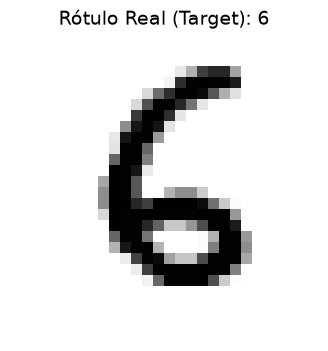

In [5]:
# Exibição do exemplo de um dígito do dataset
digito_exemplo = X[126]  # Selecionando o dígito na posição 126
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(digito_imagem, cmap='binary') # cmap='binary' mostra preto no branco
plt.title(f"Rótulo Real (Target): {y[126]}", fontsize=14)
plt.axis('off') # Oculta os eixos cartesianos
plt.show()

In [6]:
# Exibição da dimensionalidade dos dados
print(f"Dimensionalidade das Features (X): {X.shape}")
print(f"Dimensionalidade dos Rótulos (y): {y.shape}")

Dimensionalidade das Features (X): (70000, 784)
Dimensionalidade dos Rótulos (y): (70000,)


In [7]:
# Balanceamento do dataset
unique, counts = np.unique(y, return_counts=True)
distribuicao = pd.DataFrame({'Digito': unique, 'Contagem': counts})
print("\nDistribuição dos dígitos no dataset:")
print(distribuicao.to_string(index=False))  # Exibe a distribuição sem o índice



Distribuição dos dígitos no dataset:
 Digito  Contagem
      0      6903
      1      7877
      2      6990
      3      7141
      4      6824
      5      6313
      6      6876
      7      7293
      8      6825
      9      6958


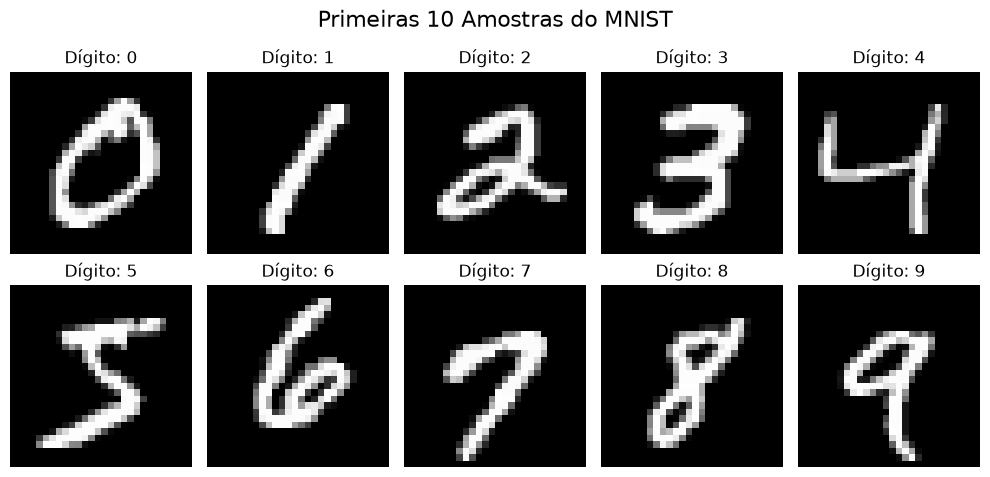

In [8]:
# Grade visual exibindo cada dígito do 0 ao 9
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()  # Achata a matriz de eixos para facilitar a iteração

for i in range(10):
    # Seleciona a primeira ocorrência do dígito i
    idx = np.where(y == i)[0][0]
    imagem = X[idx].reshape(28,28) # remodela a imagem para 28x28

    axes[i].imshow(imagem, cmap='gray')  # Exibe a imagem em escala de cinza
    axes[i].set_title(f"Dígito: {i}")
    axes[i].axis('off')  # Oculta os eixos
    
plt.suptitle("Primeiras 10 Amostras do MNIST", fontsize=16)
plt.tight_layout()
plt.show()

**Estrutura dos Dados e Representação Vetorial no MNIST**  
Escala de Intensidade de Pixels (0 a 255):  
Cada pixel da imagem é representado por um número inteiro no intervalo [0, 255]. Na escala de cinza do MNIST, o valor 0 representa a cor preta absoluta (fundo), enquanto o valor 255 representa a cor branca pura (traço do dígito escrito a mão). Valores intermediários representam variações de cinza (suavização nas bordas das letras).
  
Vetorização de Imagens:  
Originalmente, cada imagem do MNIST é uma matriz bidimensional de 28 linhas por 28 colunas, totalizando 784 pixels (28 x 28 = 784). Para ser processada por algoritmos de machine learning clássicos, essa matriz é "achatada" (flattening), transformando-se em um vetor unidimensional de 784 colunas. Cada uma dessas 784 colunas atua como uma feature (característica) numérica independente do modelo.

## Fase 02 - Pré-processamento e divisão dos dados

In [11]:
# Dividimos 20% para Teste e 80% para Treino + Validação (X_temp)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [31]:
# Dos 80% restantes (X_temp), separar 12.5% para Validação.
# 12.5% de 80% equivale a exatamente 10% do total do dataset original (70% treino, 10% val, 20% teste).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print(f"Amostras de Treino: {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})")
print(f"Amostras de Teste: {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})")
print(f"Amostras de Validação: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})")

Amostras de Treino: 49000 (70%)
Amostras de Teste: 14000 (20%)
Amostras de Validação: 7000 (10%)


In [13]:
# Normalização dos Pixels [0.0, 1.0]
# Instanciamos o MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.0, 1.0))

In [14]:
# IMPORTANTE: Ajustar (fit) o scaler APENAS no conjunto de treino
X_train_norm = scaler.fit_transform(X_train)

In [15]:
# Transformar validação e teste usando os parâmetros aprendidos no treino
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

print("\nEscalonamento concluído:")
print(f"Valor mínimo no treino normalizado: {X_train_norm.min()}")
print(f"Valor máximo no treino normalizado: {X_train_norm.max()}")


Escalonamento concluído:
Valor mínimo no treino normalizado: 0.0
Valor máximo no treino normalizado: 1.0


**A Importância do Escalonamento/Normalização de Atributos**  
Convergência de Algoritmos de Otimização (Modelos Lineares, Redes Neutrais e Regressão Logística):  
Algoritmos baseados em Gradiente Descendente calculam derivadas em relação aos pesos dos atributos para otimizar a função de perda. Quando as features possuem magnitudes elevadas (como valores de pixels entre 0 e 255), os gradientes gerados durante o backpropagation ou atualizações de pesos tornam-se desproporcionalmente grandes. Isso gera oscilações bruscas nos passos do gradiente, dificultando ou impedindo a convergência para o mínimo global/local. Normalizar a escala para [0.0, 1.0] garante atualização suave e homogênea dos pesos.  

Algoritmos Baseados em Distância Métrica (KNN, SVM, K-Means):  
Modelos que dependem de métricas como a Distância Euclidiana do espaço vetorial, calculam a proximidade geométrica entre pontos. Se a escala não estiver delimitada, atributos com maiores amplitudes numéricas dominam completamente a distância final em relação aos atributos com menores variações, mesmo que estes últimos contenham informações críticas de diferenciação de padrões.  

Estratificação por Classe:  
Garante que a proporção das 10 classes (dígitos 0 a 9) no treino, validação e teste reflita fielmente a distribuição do dataset original. Isso evita cenários onde uma classe rara fique sub-representada no conjunto de teste, gerando métricas de avaliação distorcidas.